In [7]:
!pip install python-dotenv

In [9]:
import os
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace

import matplotlib.pyplot as plt
import pandas as pd

# Cargar variables de entorno
load_dotenv("/home/jovyan/work/.env")

MONGO_URI = os.getenv("MONGO_URI")
DB_NAME = os.getenv("DB_NAME")
PROCESSED_COLLECTION = os.getenv("PROCESSED_COLLECTION")

# Verificación
print("Base de datos:", DB_NAME)
print("Colección:", PROCESSED_COLLECTION)

# Crear sesión Spark
spark = (
    SparkSession.builder
    .appName("Heatmap_Correlacion_Jocelyn")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages",
            "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

# Leer colección limpia
df = (
    spark.read.format("mongodb")
    .option("database", DB_NAME)
    .option("collection", PROCESSED_COLLECTION)
    .load()
)

print("Registros cargados:", df.count())
df.printSchema()

Base de datos: proyecto_bigdata
Colección: Contenedor_Autos_Limpio
Registros cargados: 1988
root
 |-- _id: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- foto_url: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- url: string (nullable = true)
 |-- usuario: string (nullable = true)
 |-- year: integer (nullable = true)



In [10]:
df_clean = df.select(
    "marca",
    "modelo",
    "year",
    "precio",
    "kilometraje",
    "url"
).dropDuplicates(["url"])

# Eliminar nulos
df_clean = df_clean.filter(col("year").isNotNull())
df_clean = df_clean.filter(col("precio").isNotNull())
df_clean = df_clean.filter(col("kilometraje").isNotNull())

# Limpiar precio
df_clean = df_clean.withColumn(
    "precio_num",
    regexp_replace(col("precio"), "[^0-9]", "").cast("double")
)

# Limpiar kilometraje
df_clean = df_clean.withColumn(
    "km_num",
    regexp_replace(col("kilometraje"), "[^0-9]", "").cast("double")
)

# Limpiar año
df_clean = df_clean.withColumn(
    "year_limpio",
    regexp_replace(col("year"), "[^0-9]", "").cast("int")
)

# Filtrar registros válidos
df_clean = df_clean.filter(col("precio_num") > 0)
df_clean = df_clean.filter(col("km_num") > 0)
df_clean = df_clean.filter(
    (col("year_limpio") >= 1990) &
    (col("year_limpio") <= 2026)
)

print("Registros limpios:", df_clean.count())

df_clean.select(
    "marca",
    "modelo",
    "precio_num",
    "km_num",
    "year_limpio"
).show(10, truncate=False)

Registros limpios: 1988
+-----+----------------------------+----------+---------+-----------+
|marca|modelo                      |precio_num|km_num   |year_limpio|
+-----+----------------------------+----------+---------+-----------+
|audi |A1 Sportback 30 Tfsi Sport  |21997.0   |272940.0 |2024       |
|audi |A1 Sportback 30 Tfsi Sport  |21997.0   |117660.0 |2024       |
|audi |A3 2.0 Tfsi Sport Auto      |18997.0   |849170.0 |2018       |
|audi |A3 1.4 35 Tfsi Stronic Auto |15897.0   |936870.0 |2018       |
|audi |A4 2.0 Tfsi 35 S-tronic     |29497.0   |450210.0 |2024       |
|audi |A5 New 2.0 Tfsi Quattro S Li|54997.0   |15000.0  |2026       |
|audi |A6 2.0 Turbo                |12977.0   |1820000.0|2015       |
|audi |E-tron Bev 95kwh 55 Quattro |57997.0   |108080.0 |2024       |
|audi |Q2 1.4 35 Tfsi Stronic Auto |24997.0   |451820.0 |2023       |
|audi |Q3                          |15987.0   |627080.0 |2016       |
+-----+----------------------------+----------+---------+---------

In [11]:
corr_pd = (
    df_clean
    .select(
        "precio_num",
        "km_num",
        "year_limpio"
    )
    .dropna()
    .limit(1000)
    .toPandas()
)

corr_matrix = corr_pd.corr()

print("Matriz de correlación:")
print(corr_matrix)

Matriz de correlación:
             precio_num    km_num  year_limpio
precio_num     1.000000  0.164463    -0.185909
km_num         0.164463  1.000000    -0.709003
year_limpio   -0.185909 -0.709003     1.000000


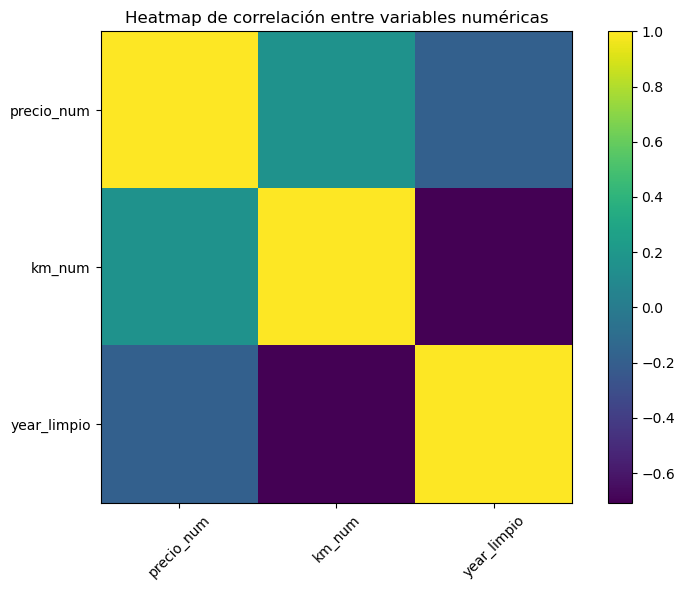

In [12]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Heatmap de correlación entre variables numéricas")

plt.tight_layout()

plt.show()

# Interpretación Heatmap

El heatmap de correlación permite analizar la relación existente entre las principales variables numéricas presentes en el conjunto de datos de AutoTec.

Los resultados muestran que el precio mantiene una relación positiva con el año del vehículo, indicando que los automóviles más recientes suelen presentar un mayor valor comercial. Por otra parte, el kilometraje presenta una relación negativa con el precio, evidenciando que los vehículos con mayor uso tienden a disminuir su valor dentro del mercado de autos usados.

Estos resultados son consistentes con el comportamiento esperado del mercado automotriz y permiten concluir que las variables año y kilometraje poseen capacidad explicativa sobre las variaciones de precio observadas en el conjunto de datos.

Desde una perspectiva de negocio, este análisis proporciona información relevante para futuras etapas de segmentación y modelado predictivo orientadas a la estimación del precio de vehículos usados.